# Resultados del árbol de decisión

Este notebook muestra la evaluación del modelo no optimizado y la visualización del árbol para el modelo no optimizado y el optimizado.

In [ ]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.tree import plot_tree

# Buscar raíz del proyecto (busca la estructura esperada)
def encontrar_base_dir():
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'src' / 'evaluacion' / 'ev_arbol_decision.py').exists():
            return candidate
    raise FileNotFoundError('No se encontró la raíz del proyecto con la estructura esperada')

base_dir = encontrar_base_dir()
ruta_datos = base_dir / 'data' / '7_agro_intelligence.csv'
df = pd.read_csv(ruta_datos, encoding='utf-8')

# Definir X e y como en los scripts de entrenamiento/evaluacion
X = df[[ 'ph_suelo', 'nitrogeno', 'fosforo', 'potasio', 'humedad_suelo',
        'radiacion_solar', 'riego_litros', 'tipo_fertilizante',
        'incidencia_plagas', 'diametro_fruto', 'peso_promedio',
        'clima_estacion' ] ]
y = df['target_calidad']

# Dividir para obtener x_test/y_test (mismo split que entrenamientos)
_, x_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Cargar modelos (no optimizado y optimizado)
ruta_modelo = base_dir / 'models' / 'arbol_decision.pkl'
ruta_modelo_opt = base_dir / 'models' / 'arbol_decision_optimizado.pkl'
modelo = joblib.load(ruta_modelo)
modelo_opt = joblib.load(ruta_modelo_opt)

print('Modelos cargados:')
print('-', ruta_modelo.name)
print('-', ruta_modelo_opt.name)


Modelos cargados:
- arbol_decision.pkl
- arbol_decision_optimizado.pkl


In [21]:
# Comparación de búsquedas: GridSearchCV vs RandomizedSearchCV
from importlib.util import spec_from_file_location, module_from_spec
module_path_opt = base_dir / 'src' / 'optimizacion' / 'op_arbol_decision.py'
spec_opt = spec_from_file_location('op_arbol_decision', module_path_opt)
optimizacion = module_from_spec(spec_opt)
spec_opt.loader.exec_module(optimizacion)

# Mostrar resumen de búsquedas (DataFrame con grid vs randomized)
display(optimizacion.resumen_busquedas)

# Mostrar métricas clave de la optimización
print('Mejor método (Grid vs Randomized):', optimizacion.metrics.get('best_method'))
print('Mejor score CV (best_cv_score):', optimizacion.metrics.get('best_cv_score'))
print('Accuracy en test del modelo optimizado:', optimizacion.metrics.get('accuracy'))
print('Mejores parámetros encontrados:', optimizacion.metrics.get('best_params'))

,metodo,mejor_score_cv,accuracy_test,mejores_parametros
0,GridSearchCV,0.35000,0.379167,"{'clasificador__criterion': 'gini', 'clasifica..."
1,RandomizedSearchCV,0.35625,0.370833,"{'clasificador__criterion': 'log_loss', 'clasi..."


Mejor método (Grid vs Randomized): RandomizedSearchCV
Mejor score CV (best_cv_score): 0.35625
Accuracy en test del modelo optimizado: 0.37083333333333335
Mejores parámetros encontrados: {'clasificador__criterion': 'log_loss', 'clasificador__max_depth': 3, 'clasificador__max_features': None, 'clasificador__min_samples_leaf': 11, 'clasificador__min_samples_split': 9}


Accuracy (no optimizado): 36.67%
Classification report (no optimizado):
              precision    recall  f1-score   support

     Desecho       0.00      0.00      0.00        76
 Exportacion       0.38      0.21      0.27        77
       Local       0.37      0.83      0.51        87

    accuracy                           0.37       240
   macro avg       0.25      0.35      0.26       240
weighted avg       0.26      0.37      0.27       240



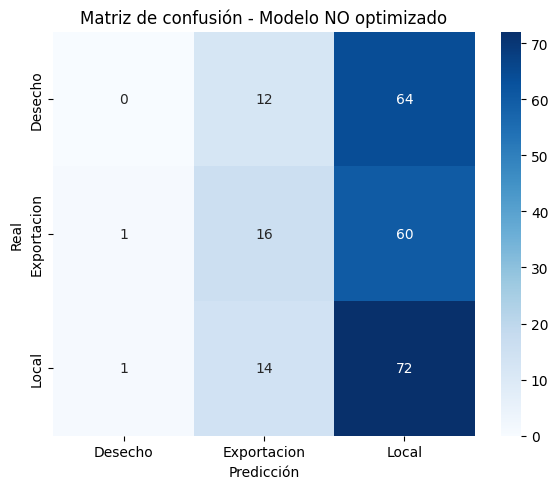

In [18]:
# Evaluación del modelo NO optimizado: matriz de confusión, reporte y accuracy
y_pred = modelo.predict(x_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)

print(f'Accuracy (no optimizado): {acc*100:.2f}%')
print('Classification report (no optimizado):')
print(report)

# Graficar matriz de confusión
labels = modelo.named_steps['clasificador'].classes_
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión - Modelo NO optimizado')
plt.tight_layout()
plt.show()

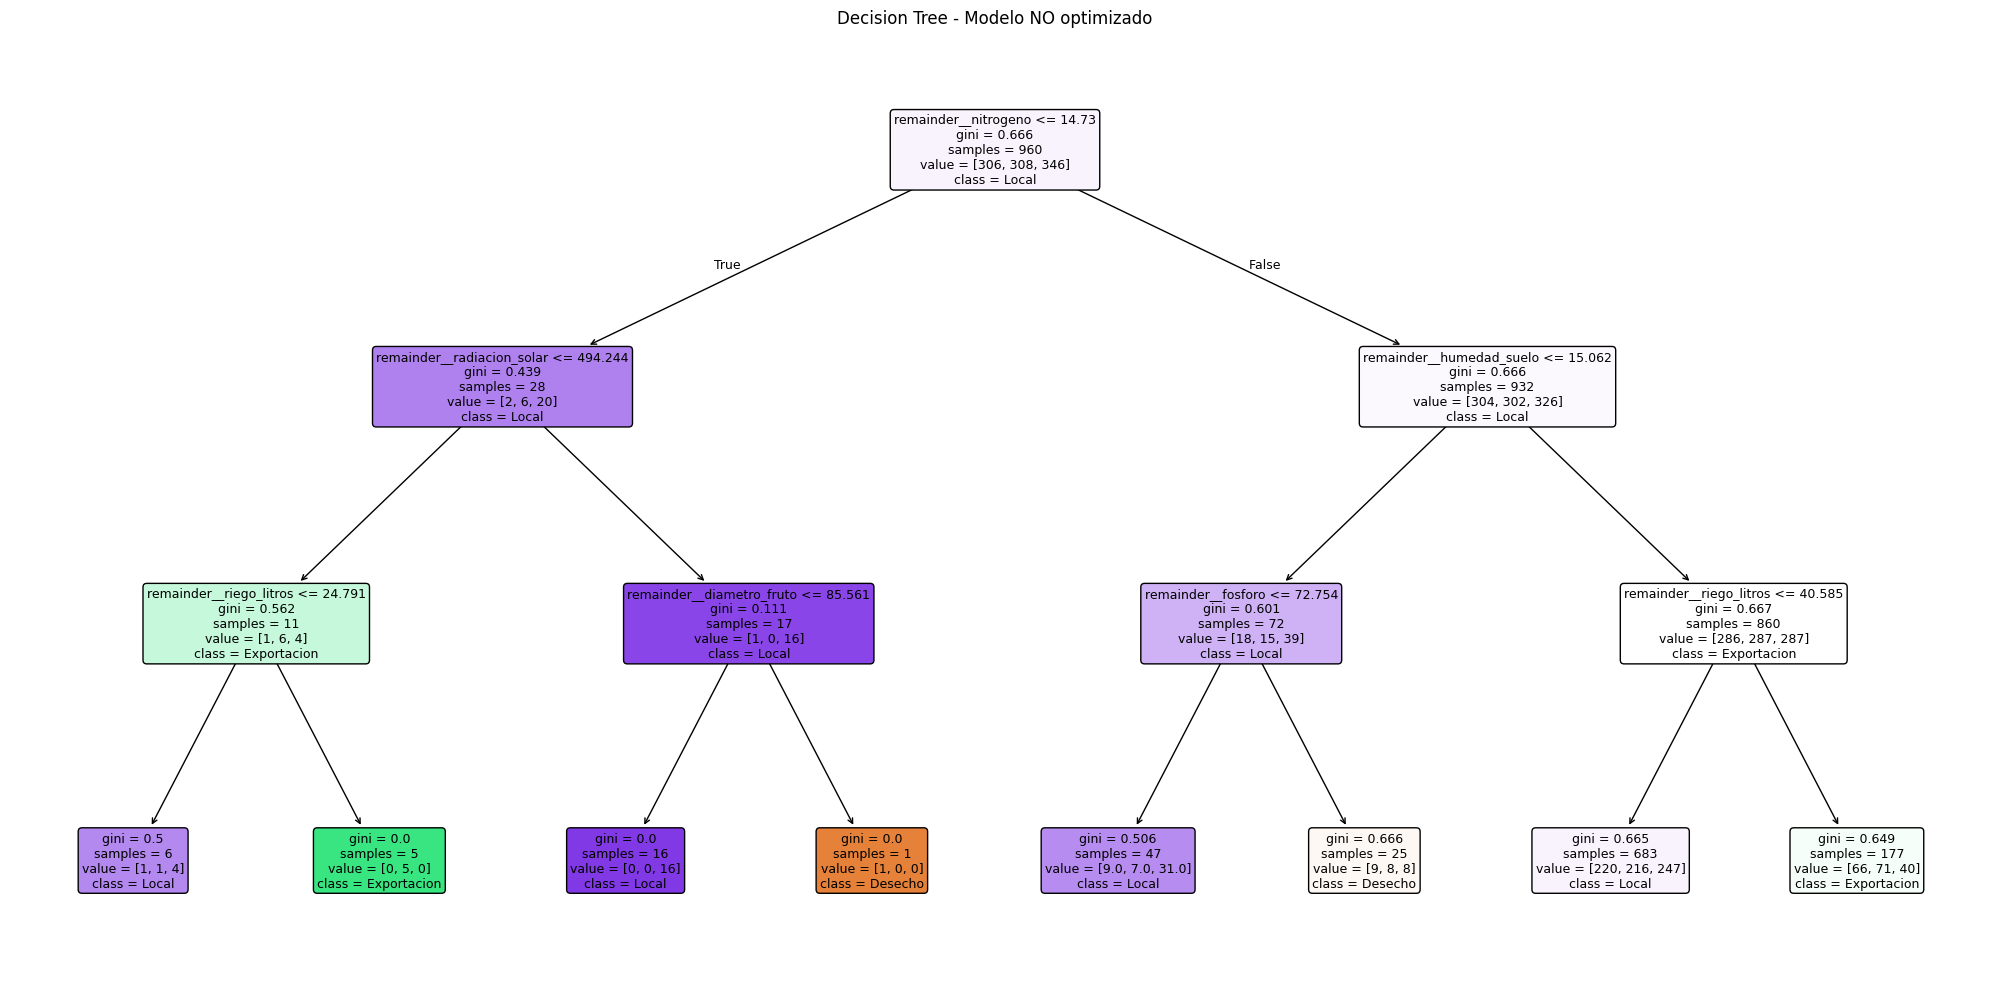

In [19]:
# Gráfico del árbol - Modelo NO optimizado
clasificador = modelo.named_steps['clasificador']
preprocesador = modelo.named_steps['preprocesamiento']
feature_names = preprocesador.get_feature_names_out()
class_names = clasificador.classes_

fig, ax = plt.subplots(figsize=(20,10))
plot_tree(clasificador, feature_names=feature_names, class_names=class_names, filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title('Decision Tree - Modelo NO optimizado')
plt.tight_layout()
plt.show()

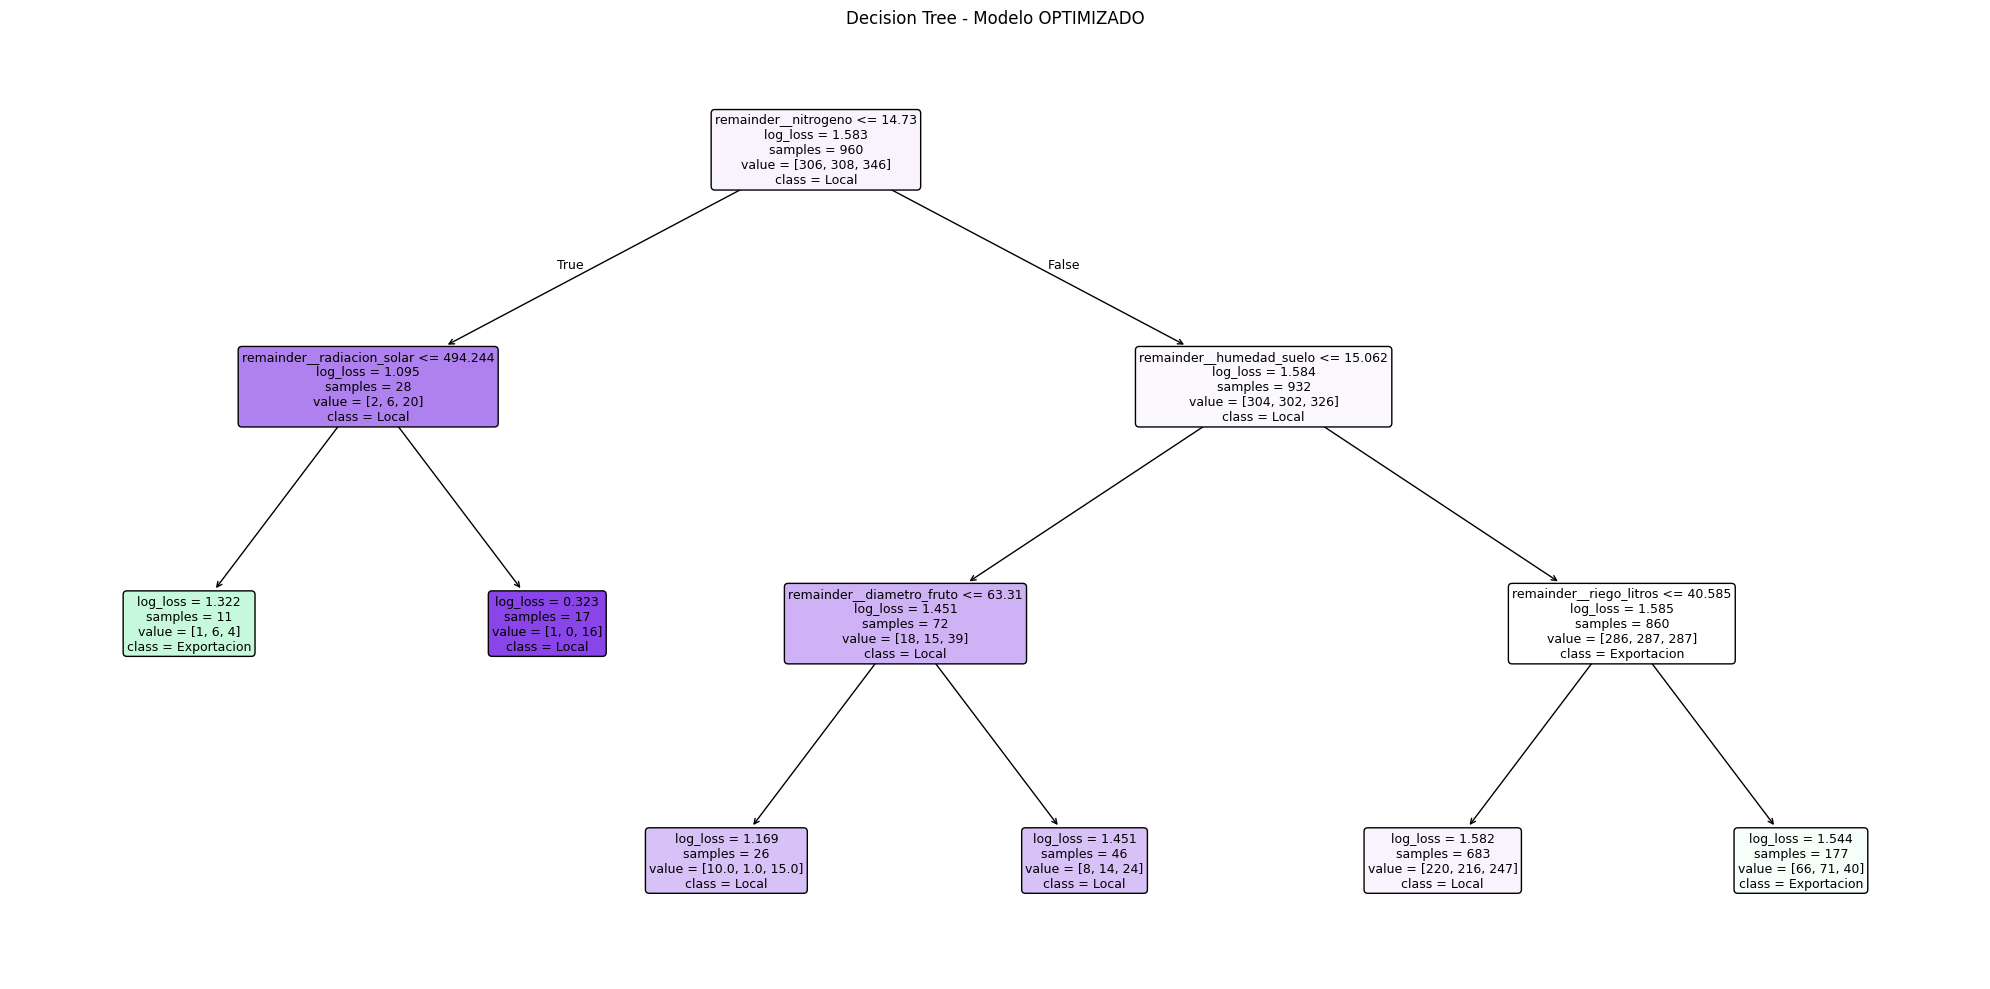

In [20]:
# Gráfico del árbol - Modelo OPTIMIZADO
clasificador_opt = modelo_opt.named_steps['clasificador']
preprocesador_opt = modelo_opt.named_steps['preprocesamiento']
feature_names_opt = preprocesador_opt.get_feature_names_out()
class_names_opt = clasificador_opt.classes_

fig, ax = plt.subplots(figsize=(20,10))
plot_tree(clasificador_opt, feature_names=feature_names_opt, class_names=class_names_opt, filled=True, rounded=True, max_depth=3, fontsize=9, ax=ax)
ax.set_title('Decision Tree - Modelo OPTIMIZADO')
plt.tight_layout()
plt.show()